#NON-llm workflow

In [33]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [34]:
# Define a TypedDict for the Batsman data structure 

#creating States for the graph

class BatsmanState(TypedDict):
    
    runs: int
    balls: int
    fours: int
    sixes: int
    
    
    strike_rate: float
    boundries_per_balls: float
    boundries_percent: float
    summary: str

In [35]:
def calculate_strike_rate(state: BatsmanState) -> BatsmanState:
    
    strike_rate=(state['runs']/ state['balls'])*100
    
    #state['strike_rate'] = strike_rate
    
    return {'strike_rate': strike_rate}

In [36]:
def calculate_boundries_per_balls(state: BatsmanState) -> BatsmanState:
    
    bpb=state['fours']+state['sixes']/state['balls']
    
    #state['boundries_per_balls'] = bpb
    
    return {'boundries_per_balls': bpb}

In [37]:
def generate_summary(state: BatsmanState) -> BatsmanState:
    
    summary=f"Batsman scored {state['runs']} runs in {state['balls']} balls with a strike rate of {state['strike_rate']:.2f} and hit {state['fours']} fours and {state['sixes']} sixes. Boundries per ball: {state['boundries_per_balls']:.2f}, Boundries percent: {state['boundries_percent']:.2f}%."
    
    return {'summary': summary}
    

In [38]:
def calculate_boundries_percent(state: BatsmanState) -> BatsmanState:
    
    bp=((((state['fours']*4)+(state['sixes']*6))/state['runs']))*100
    
    #state['boundries_percent'] = bp
    
    return {'boundries_percent': bp}

In [39]:
# creating the graph and adding nodes to it

graph = StateGraph(BatsmanState)

# adding nodes to the graph

graph.add_node("calculate_strike_rate",calculate_strike_rate)
graph.add_node("calculate_boundries_per_balls",calculate_boundries_per_balls)
graph.add_node("calculate_boundries_percent",calculate_boundries_percent)
graph.add_node("generate_summary",generate_summary)


# defining the edges between the nodes


graph.add_edge(START,"calculate_strike_rate")
graph.add_edge(START,"calculate_boundries_per_balls")
graph.add_edge(START,"calculate_boundries_percent")


graph.add_edge("calculate_strike_rate","generate_summary")
graph.add_edge("calculate_boundries_per_balls","generate_summary")
graph.add_edge("calculate_boundries_percent","generate_summary")


graph.add_edge("generate_summary",END)

# COMPILE THE GRAPH

workflow=graph.compile()



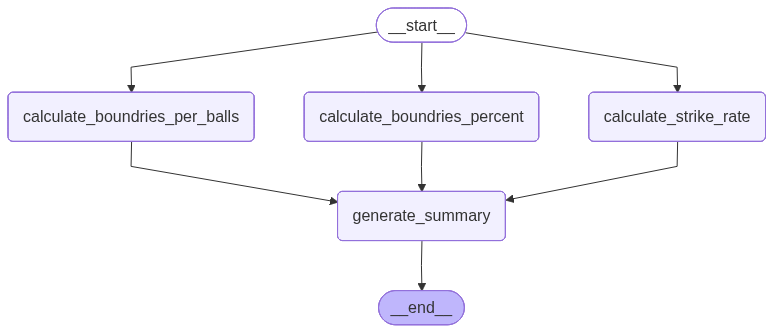

In [40]:
workflow

In [41]:
#executing the workflow with some input data

initial_state = {
    'runs': 120,    
    'balls': 80,
    'fours': 10,
    'sixes': 5,
    

}

workflow.invoke(initial_state)

{'runs': 120,
 'balls': 80,
 'fours': 10,
 'sixes': 5,
 'strike_rate': 150.0,
 'boundries_per_balls': 10.0625,
 'boundries_percent': 58.333333333333336,
 'summary': 'Batsman scored 120 runs in 80 balls with a strike rate of 150.00 and hit 10 fours and 5 sixes. Boundries per ball: 10.06, Boundries percent: 58.33%.'}